# Notebook to Generate Results and Figures for FATES OAAT Manuscript

## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import string
import xarray as xr
import matplotlib.pyplot as plt

import fates_calibration_library.oaat_functions as oaat
import fates_calibration_library.plotting_functions as plotting
import fates_calibration_library.utils as utils
import fates_calibration_library.clm_functions as clm
import fates_calibration_library.biome_functions as biome

## Set Up
File locations and ensemble information

In [2]:
# parameter directory
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'

# history output directory
hist_dir = '/glade/work/afoster/FATES_calibration/history_files/compiled_files'

# output directory for figures
fig_dir = '/glade/work/afoster/FATES_calibration/figures/oaat_figs'

In [3]:
# dictionary with information about each ensemble
ensemble_dict = {
    'fates': {
        'param_list': os.path.join(param_dir, "param_list_sci.1.85.1_api.40.0.0_updates.xls"),
        'key': os.path.join(param_dir, 'fates_oaat', 'fates_oaat_key.csv'),
        'name': 'fates_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'fates_oaat'),
        'param_prefix': 'FATES_OAAT_',
        'default_param': xr.open_dataset(os.path.join(param_dir,
                                                      'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai.nc'))
    },
    'fates_clmpars': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_info.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'fates_oaat_clmpars',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    },
    'clm': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_info.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'clm_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    }
}
fates = ensemble_dict['fates']
fates_clm = ensemble_dict['fates_clmpars']
clm_oaat = ensemble_dict['clm']

In [80]:
# config file with variable information in it
var_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/model_conversion.yaml'
var_dict = utils.get_config_file(var_config)

obs_config_file = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/ilamb_conversion.yaml'
obs_config = utils.get_config_file(obs_config_file)

fates_clm_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_clm_index.yaml'
fates_to_clm = utils.get_config_file(fates_clm_config)

clm_pft_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/clm_index_to_name.yaml'
clm_pfts = utils.get_config_file(clm_pft_config)

variables = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM',
             'ASA', 'RN', 'BTRANMN', 'QRUNOFF', 'QSOIL', 'QVEGT',
             'QVEGE', 'WUE']

# all variables
out_vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM', 'ASA',
            'FSDS', 'FSR', 'FSA', 'FIRE', 'RLNS', 'RN', 'BTRANMN', 'TV', 'Temp',
            'RH2M', 'Precip', 'QRUNOFF', 'QSOIL', 'QVEGT', 'QVEGE']

special_vars = ['fates_vcmaxse_clmdef', 'fates_vcmaxhd_clmdef',
               'fates_vcmaxha_clmdef', 'fates_jmaxse_clmdef',
               'fates_jmaxhd_clmdef', 'fates_jmaxha_clmdef',
               'fates_new_def']

In [5]:
# analagous parameters between CLM and FATES
corresponding_params = {
    'leafcn': 'fates_leaf_vcmax25top',
    'dleaf': 'fates_turb_leaf_diameter',
    'fnps': 'fates_leaf_fnps',
    'jmaxha': 'fates_leaf_jmaxha',
    'jmaxhd': 'fates_leaf_jmaxhd',
    'jmaxse_sf': 'fates_leaf_jmaxse',
    'medlynintercept': 'fates_leaf_stomatal_intercept',
    'medlynslope': 'fates_leaf_stomatal_slope_medlyn',
    'rholnir': 'fates_rad_leaf_rhonir',
    'rholvis': 'fates_rad_leaf_rhovis',
    'rhosnir': 'fates_rad_stem_rhonir',
    'rhosvis': 'fates_rad_stem_rhovis',
    'slatop': 'fates_leaf_slatop',
    'smpsc': 'fates_nonhydro_smpsc',
    'smpso': 'fates_nonhydro_smpso',
    'taulnir': 'fates_rad_leaf_taunir',
    'taulvis': 'fates_rad_leaf_tauvis',
    'tausnir': 'fates_rad_stem_taunir',
    'tausvis': 'fates_rad_stem_tauvis',
    'vcmaxha': 'fates_leaf_vcmaxha',
    'vcmaxhd': 'fates_leaf_vcmaxhd',
    'vcmaxse_sf': 'fates_leaf_vcmaxse',
    'xl': 'fates_rad_leaf_xl'}

clm_params = list(corresponding_params.keys())

### Read in parameter information

In [110]:
# oaat keys
fates_key = pd.read_csv(fates['key'], index_col=0)
fates_key2 = pd.read_csv('/glade/work/afoster/FATES_calibration/parameter_files/fates_oaat_2/fates_oaat_2_key.csv', index_col=0)
fates_key3 = pd.read_csv('/glade/work/afoster/FATES_calibration/parameter_files/fates_oaat_3/fates_oaat_3_key.csv', index_col=0)
clm_key = pd.read_csv(clm_oaat['key'], header=None)
clm_key.columns = ['ensemble', 'parameter_name', 'type']

# fates_key = fates_key[~fates_key.parameter_name.isin(special_vars)].copy()

# parameter information plus ensemble member
clm_param_dat = oaat.get_clm_param_dat(fates_clm['param_list'], clm_key)
fates_param_dat = oaat.get_fates_param_dat(fates['param_list'], fates_key)
fates_param_dat2 = oaat.get_fates_param_dat(fates['param_list'], fates_key2)
fates_param_dat3 = oaat.get_fates_param_dat(fates['param_list'], fates_key3)

# just parameter information
all_params = oaat.get_all_parameters(clm_param_dat, fates_param_dat)

## Analysis

### What is the sparse grid?

In [111]:
whit_biome = xr.open_dataset('/glade/work/afoster/FATES_calibration/observations/whittaker_biomes_2deg.nc')

mesh_file = '/glade/work/afoster/FATES_calibration/mesh_files/lnd_mesh.nc'
mesh = xr.open_dataset(mesh_file)
mesh = mesh.where(mesh.elementMask == 1, drop=True)

centerCoords = mesh.centerCoords.values
grids = mesh.elementCount.values

mesh_lats = [coord[1] for coord in centerCoords]
mesh_lons = [coord[0] for coord in centerCoords]

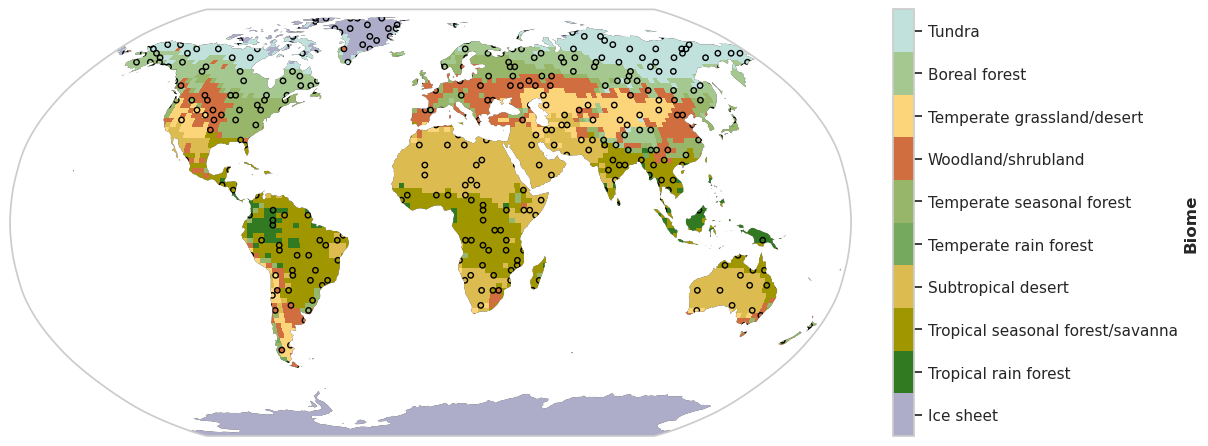

In [112]:
biome.plot_whittaker_biomes(whit_biome.biome, mesh_lats, mesh_lons, height=7, width=12)
plt.savefig(os.path.join(fig_dir, 'OAAT_Sparse_Grid_Biomes.png'), bbox_inches='tight')

### How many parameters did we perturb?

In [113]:
print("We perturbed", oaat.count_parameters(fates_key), "FATES parameters")

We perturbed 143 FATES parameters


In [114]:
print("We perturbed", oaat.count_parameters(clm_key), "CLM parameters")

We perturbed 204 CLM parameters


### How many parameters if we treated each PFT-parameter independently?

In [119]:
print(oaat.count_if_PFT_independent(fates_key, fates['default_param']), "FATES parameters")

1748 FATES parameters


In [120]:
print(oaat.count_if_PFT_independent(clm_key, clm_oaat['default_param'], FATES=False), "CLM parameters")

1374 CLM parameters


### Read in data

In [122]:
# FATES SP ensemble with FATES parameters
fates_glob, fates_mean, fates_iav = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_area_means.nc"),
                                                  fates_param_dat, variables, fates['default'], special_vars)

fates_glob2, fates_mean2, fates_iav2 = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_2_area_means.nc"),
                                                  fates_param_dat2, variables, fates['default'])
fates_glob3, fates_mean3, fates_iav3 = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_3_area_means.nc"),
                                                  fates_param_dat3, variables, fates['default'])

# FATES SP ensemble with CLM parameters
fatesclm_glob, fatesclm_mean, fatesclm_iav = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])
fatesclm_glob2, fatesclm_mean2, fatesclm_iav2 = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_2_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])
fatesclm_glob3, fatesclm_mean3, fatesclm_iav3 = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_3_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])

# CLM SP ensemble with CLM parameters
clm_glob, clm_mean, clm_iav = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_oaat['name']}_area_means.nc"),
                                       clm_param_dat, variables, clm_oaat['default'])

# combine FATES ensembles
fates_glob_combo = oaat.get_combined(fates_glob, fatesclm_glob, 'fates parameters', 'clm parameters')
fates_glob_combo_mean = oaat.get_combined(fates_mean, fatesclm_mean, 'fates parameters', 'clm parameters')
fates_glob_combo_iav = oaat.get_combined(fates_iav, fatesclm_iav, 'fates parameters', 'clm parameters')

fates_glob_combo2 = oaat.get_combined(fates_glob2, fatesclm_glob2, 'fates parameters', 'clm parameters')
fates_glob_combo_mean2 = oaat.get_combined(fates_mean2, fatesclm_mean2, 'fates parameters', 'clm parameters')
fates_glob_combo_iav2 = oaat.get_combined(fates_iav2, fatesclm_iav2, 'fates parameters', 'clm parameters')

fates_glob_combo3 = oaat.get_combined(fates_glob3, fatesclm_glob3, 'fates parameters', 'clm parameters')
fates_glob_combo_mean3 = oaat.get_combined(fates_mean3, fatesclm_mean3, 'fates parameters', 'clm parameters')
fates_glob_combo_iav3 = oaat.get_combined(fates_iav3, fatesclm_iav3, 'fates parameters', 'clm parameters')

fates_default = fates_mean.isel(ensemble=0)
clm_default = clm_mean.isel(ensemble=0)

In [93]:
# get pandas data frame with global annual means
active_df = oaat.get_active_ensemble_df(clm_mean, fates_glob_combo_mean)

In [94]:
fates_active_ens2 = fates_glob_combo_mean2.to_pandas().reset_index().drop(columns=['ensemble'])
fates_active_ens2['model'] = 'FATES'

fates_active_ens3 = fates_glob_combo_mean3.to_pandas().reset_index().drop(columns=['ensemble'])
fates_active_ens3['model'] = 'FATES'

## Find non-zero parameters

In [95]:
# find non-zero parameters for all simulations
nonzero_params = oaat.get_params(fates_glob, fatesclm_glob, clm_glob)
all_params = oaat.classify_params(all_params, nonzero_params)
fates_params = np.append(nonzero_params['fates'], nonzero_params['fates_clm'])

### How many active CLM parameters?

In [17]:
print("In total:", len(nonzero_params['clm']), "influenced CLM-SP")

In total: 114 influenced CLM-SP


In [18]:
print("In total:", len(nonzero_params['fates_clm']), "influenced CLM-FATES-SP")

In total: 56 influenced CLM-FATES-SP


In [19]:
print("Of these:", len(nonzero_params['common']), "influenced both")

Of these: 55 influenced both


In [20]:
print("and", len(nonzero_params['clm_only']), "influenced only CLM")

and 59 influenced only CLM


### How many active FATES parameters?

In [21]:
print(len(nonzero_params['fates']), "influenced CLM-FATES-SP")

46 influenced CLM-FATES-SP


In [96]:
nonzero_params['fates']

array(['fates_allom_blca_expnt_diff', 'fates_allom_d2bl2',
       'fates_allom_d2ca_coefficient_max', 'fates_allom_d2h1',
       'fates_allom_d2h2', 'fates_allom_d2h3',
       'fates_allom_dbh_maxheight', 'fates_allom_fnrt_prof_a',
       'fates_allom_fnrt_prof_b', 'fates_allom_h2cd1', 'fates_leaf_fnps',
       'fates_leaf_jmaxha', 'fates_leaf_jmaxhd', 'fates_leaf_jmaxse',
       'fates_leaf_photo_temp_acclim_timescale', 'fates_leaf_slamax',
       'fates_leaf_slatop', 'fates_leaf_stomatal_intercept',
       'fates_leaf_stomatal_slope_medlyn', 'fates_leaf_vcmax25top',
       'fates_leaf_vcmaxha', 'fates_leaf_vcmaxhd', 'fates_leaf_vcmaxse',
       'fates_leafn_vert_scaler_coeff1', 'fates_leafn_vert_scaler_coeff2',
       'fates_maintresp_leaf_atkin2017_baserate',
       'fates_maintresp_leaf_vert_scaler_coeff1',
       'fates_maintresp_leaf_vert_scaler_coeff2', 'fates_nonhydro_smpsc',
       'fates_nonhydro_smpso', 'fates_rad_leaf_clumping_index',
       'fates_rad_leaf_rhonir', 'fates_

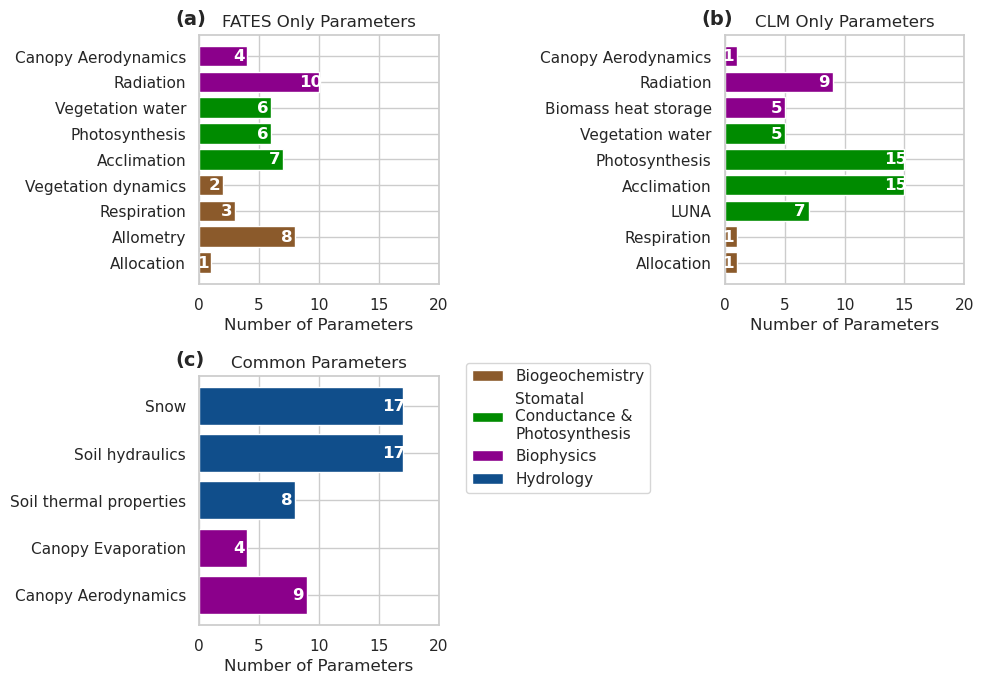

In [22]:
plotting.plot_oaat_params(all_params, nonzero_params)
plt.savefig(os.path.join(fig_dir, 'OAAT_Parameters.png'))

## Look at global annual ensemble ranges

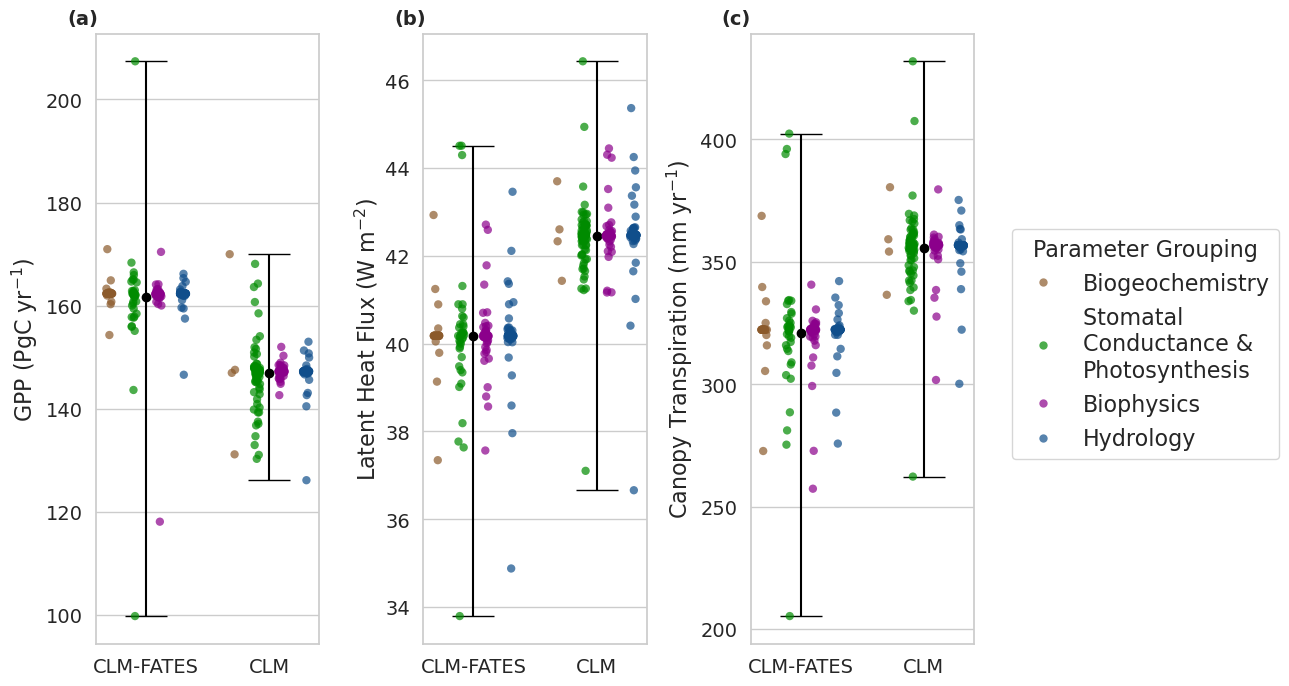

In [23]:
plotting.plot_ensemble_variance(active_df, 'CLM-FATES', 'CLM', fates_default, clm_default,
                                ['GPP', 'EFLX_LH_TOT', 'QVEGT'], var_dict)
plt.savefig(os.path.join(fig_dir, 'GPP_EFLX_LH.png'), bbox_inches="tight")

### Report some ranges

In [24]:
# calculate ranges of all variables
range_df = oaat.get_both_ranges(active_df, variables)

In [25]:
fates_df = active_df[active_df.model == 'FATES'].copy()
clm_df = active_df[active_df.model == 'CLM'].copy()

In [26]:
oaat.get_pct_diff(fates_df, 'GPP', fates_default, tol=1.0)

(8.37696335078534, 16)

In [27]:
oaat.get_pct_diff(clm_df, 'GPP', clm_default, tol=1.0)

(9.90566037735849, 21)

In [28]:
oaat.print_ensemble_range(range_df, 'FATES', 'GPP',
                          var_dict['GPP']['global_units'])

FATES GPP ranges from 99.81 to 207.4 PgC yr$^{-1}$
This is a range of  107.59 PgC yr$^{-1}$
And a mean of  161.74 PgC yr$^{-1}$
And a standard devaiation of  6.91 PgC yr$^{-1}$
And a variance of  47.72 PgC yr$^{-1}$
And an IQR of  0.24 PgC yr$^{-1}$


In [29]:
oaat.print_ensemble_range(range_df, 'CLM', 'GPP',
                          var_dict['GPP']['global_units'])

CLM GPP ranges from 126.16 to 169.99 PgC yr$^{-1}$
This is a range of  43.83 PgC yr$^{-1}$
And a mean of  146.97 PgC yr$^{-1}$
And a standard devaiation of  4.63 PgC yr$^{-1}$
And a variance of  21.43 PgC yr$^{-1}$
And an IQR of  0.47 PgC yr$^{-1}$


In [30]:
oaat.print_ensemble_range(range_df, 'FATES', 'EFLX_LH_TOT',
                          var_dict['EFLX_LH_TOT']['global_units'])

FATES EFLX_LH_TOT ranges from 33.79 to 44.51 W m$^{-2}$
This is a range of  10.72 W m$^{-2}$
And a mean of  40.17 W m$^{-2}$
And a standard devaiation of  1.09 W m$^{-2}$
And a variance of  1.18 W m$^{-2}$
And an IQR of  0.1 W m$^{-2}$


In [31]:
oaat.print_ensemble_range(range_df, 'CLM', 'EFLX_LH_TOT',
                          var_dict['EFLX_LH_TOT']['global_units'])

CLM EFLX_LH_TOT ranges from 36.66 to 46.43 W m$^{-2}$
This is a range of  9.77 W m$^{-2}$
And a mean of  42.45 W m$^{-2}$
And a standard devaiation of  0.82 W m$^{-2}$
And a variance of  0.68 W m$^{-2}$
And an IQR of  0.12 W m$^{-2}$


In [32]:
oaat.print_ensemble_range(range_df, 'FATES', 'QVEGT',
                          var_dict['QVEGT']['global_units'])

FATES QVEGT ranges from 205.23 to 402.38 mm yr$^{-1}$
This is a range of  197.15 mm yr$^{-1}$
And a mean of  320.96 mm yr$^{-1}$
And a standard devaiation of  17.09 mm yr$^{-1}$
And a variance of  292.19 mm yr$^{-1}$
And an IQR of  0.73 mm yr$^{-1}$


In [33]:
oaat.print_ensemble_range(range_df, 'CLM', 'QVEGT',
                          var_dict['QVEGT']['global_units'])

CLM QVEGT ranges from 262.23 to 431.93 mm yr$^{-1}$
This is a range of  169.7 mm yr$^{-1}$
And a mean of  355.5 mm yr$^{-1}$
And a standard devaiation of  12.72 mm yr$^{-1}$
And a variance of  161.7 mm yr$^{-1}$
And an IQR of  1.56 mm yr$^{-1}$


In [34]:
oaat.print_ensemble_range(range_df, 'CLM', 'WUE',
                          var_dict['WUE']['global_units'])

CLM WUE ranges from 0.3 to 0.56 PgC mm H$_2$O$^{-1}$
This is a range of  0.26 PgC mm H$_2$O$^{-1}$
And a mean of  0.41 PgC mm H$_2$O$^{-1}$
And a standard devaiation of  0.02 PgC mm H$_2$O$^{-1}$
And a variance of  0.0 PgC mm H$_2$O$^{-1}$
And an IQR of  0.0 PgC mm H$_2$O$^{-1}$


In [35]:
oaat.print_ensemble_range(range_df, 'FATES', 'WUE',
                          var_dict['WUE']['global_units'])

FATES WUE ranges from 0.4 to 0.63 PgC mm H$_2$O$^{-1}$
This is a range of  0.23 PgC mm H$_2$O$^{-1}$
And a mean of  0.5 PgC mm H$_2$O$^{-1}$
And a standard devaiation of  0.02 PgC mm H$_2$O$^{-1}$
And a variance of  0.0 PgC mm H$_2$O$^{-1}$
And an IQR of  0.0 PgC mm H$_2$O$^{-1}$


## Contribution to overall variance

### GPP

In [36]:
# cumulative variance and number of parameters to get to 90% variance
CLMGPP_90 = oaat.find_cumulative_params(nonzero_params['clm'], 'GPP', clm_mean)
FATESGPP_90 = oaat.find_cumulative_params(fates_params, 'GPP', fates_glob_combo_mean)

In [37]:
print("CLM requires", len(CLMGPP_90), "parameters to achieve 90% variance in GPP")

CLM requires 14 parameters to achieve 90% variance in GPP


In [38]:
print("FATES requires", len(FATESGPP_90), "parameters to achieve 90% variance in GPP")

FATES requires 3 parameters to achieve 90% variance in GPP


In [39]:
print("FATES top GPP parameters:", FATESGPP_90)

FATES top GPP parameters: ['fates_leaf_vcmax25top' 'fates_rad_leaf_clumping_index'
 'fates_leafn_vert_scaler_coeff2']


### Soil water

In [40]:
CLMSW_90 = oaat.find_cumulative_params(nonzero_params['clm'], 'SOILWATER_10CM', clm_mean)
FATESSW_90 = oaat.find_cumulative_params(fates_params, 'SOILWATER_10CM', fates_glob_combo_mean)

In [41]:
print("CLM requires", len(CLMSW_90), "parameters to achieve 90% variance in soil water")

CLM requires 9 parameters to achieve 90% variance in soil water


In [42]:
print("FATES requires", len(FATESSW_90), "parameters to achieve 90% variance in soil water")

FATES requires 9 parameters to achieve 90% variance in soil water


### Canopy transpiration

In [43]:
CLMQVEGT_90 = oaat.find_cumulative_params(nonzero_params['clm'], 'QVEGT', clm_mean)
FATESQVEGT_90 = oaat.find_cumulative_params(fates_params, 'QVEGT', fates_glob_combo_mean)

In [44]:
print("CLM requires", len(CLMQVEGT_90), "parameters to achieve 90% variance in canopy transpiration")
print("FATES requires", len(FATESQVEGT_90), "parameters to achieve 90% variance in canopy transpiration")

CLM requires 14 parameters to achieve 90% variance in canopy transpiration
FATES requires 9 parameters to achieve 90% variance in canopy transpiration


### Canopy evaporation

In [45]:
CLMQVEGE_90 = oaat.find_cumulative_params(nonzero_params['clm'], 'QVEGE', clm_mean)
FATESQVEGE_90 = oaat.find_cumulative_params(fates_params, 'QVEGE', fates_glob_combo_mean)

In [46]:
print("CLM requires", len(CLMQVEGE_90), "parameters to achieve 90% variance in QVEGE")

CLM requires 3 parameters to achieve 90% variance in QVEGE


In [47]:
print("CLM top QVEGE parameters:", CLMQVEGE_90)

CLM top QVEGE parameters: ['maximum_leaf_wetted_fraction' 'liq_canopy_storage_scalar' 'dleaf']


In [48]:
print("FATES requires", len(FATESQVEGE_90), "parameters to achieve 90% variance in QVEGE")

FATES requires 3 parameters to achieve 90% variance in QVEGE


In [49]:
print("FATES top QVEGE parameters:", FATESQVEGE_90)

FATES top QVEGE parameters: ['maximum_leaf_wetted_fraction' 'liq_canopy_storage_scalar'
 'fates_turb_leaf_diameter']


In [50]:
variance_df = oaat.get_all_cumulative_variance(variables,
                                               nonzero_params['clm'],
                                               clm_mean, fates_params,
                                               fates_glob_combo_mean)

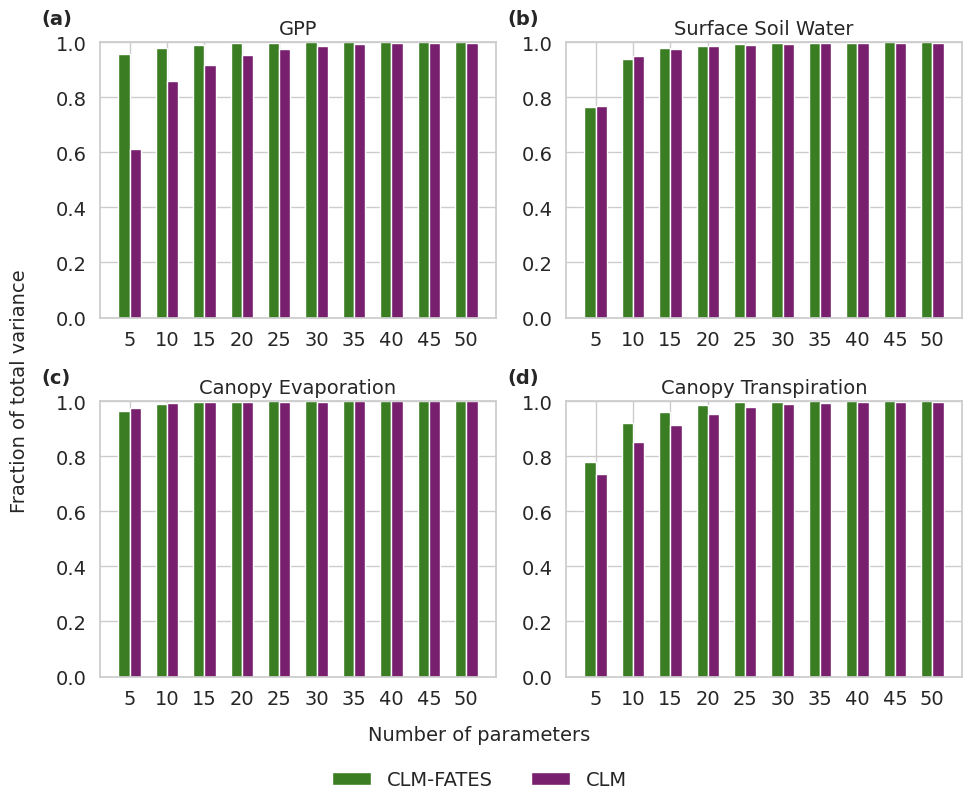

In [51]:
plotting.plot_cumulative_variance(['GPP', 'SOILWATER_10CM', 'QVEGE', 'QVEGT'], variance_df, var_dict)
plt.savefig(os.path.join(fig_dir, 'cumulative_variance.png'), bbox_inches='tight')

## Top Parameters

In [52]:
# calculate global max - min differences
fates_meandiffs = oaat.get_min_max_diff(fates_glob_combo_mean, 'FATES')
clm_meandiffs = oaat.get_min_max_diff(clm_mean, 'CLM')

In [53]:
variable = 'GPP'
n = 10

fates_top10 = oaat.get_top_n(fates_glob_combo_mean, fates_meandiffs, variable,
                             n, fates_glob_combo_mean.sel(ensemble=0))
clm_top10 = oaat.get_top_n(clm_mean, clm_meandiffs, variable, n,
                           clm_mean.sel(ensemble=0))

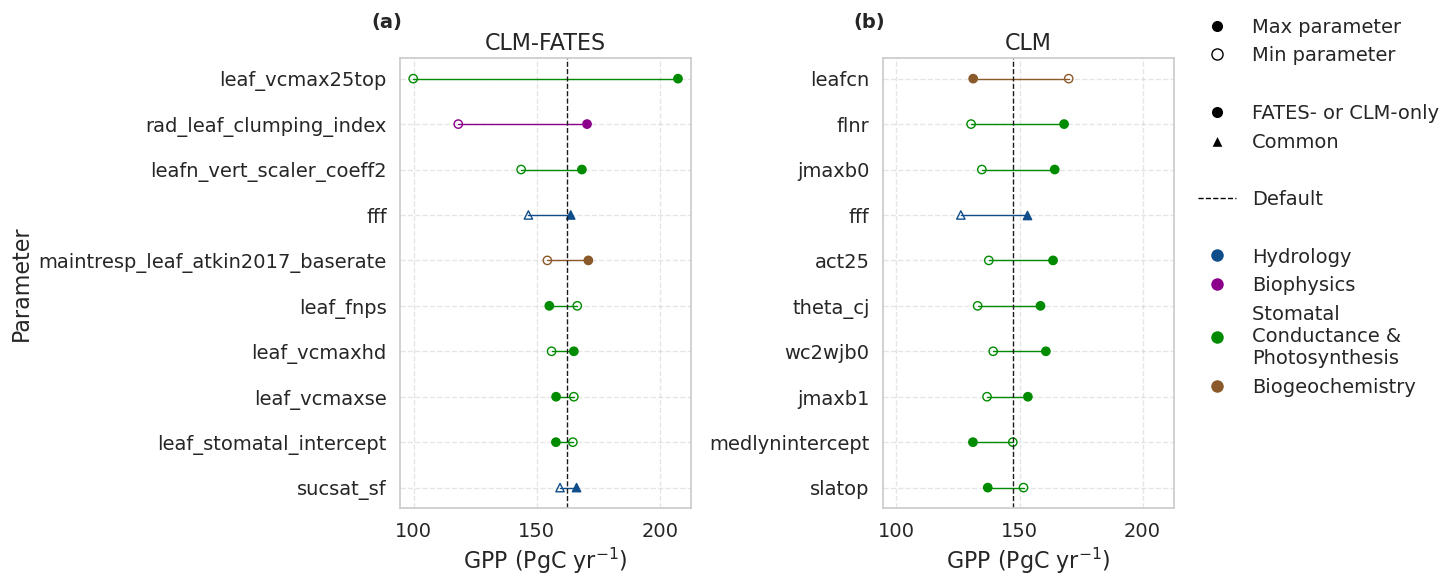

In [55]:
plotting.plot_2_top_n(fates_top10, clm_top10, fates_glob_combo_mean.sel(ensemble=0),
                      clm_mean.sel(ensemble=0), all_params, variable,
                      var_dict[variable]['long_name'],
                      var_dict[variable]['global_units'])

plt.savefig(os.path.join(fig_dir, 'GPP_top_10.png'), bbox_inches='tight')

### Top Parameters by Biome

In [56]:
# read in biome datasets
fates_biome, fates_biome_mean, fates_biome_iav = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_biome_area_means.nc"),
                                                                           fates_param_dat, variables, fates['default'], special_vars)
fatesclm_biome, fatesclm_biome_mean, fatesclm_biome_iav = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_biome_area_means.nc"),
                                                                                    clm_param_dat, variables, fates_clm['default'])
clm_biome, clm_biome_mean, clm_biome_iav = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_oaat['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, clm_oaat['default'])

# combine FATES ensembles
fates_biome_combo_mean = oaat.get_combined(fates_biome_mean, fatesclm_biome_mean, 'fates parameters', 'clm parameters')
fates_biome_combo_iav = oaat.get_combined(fates_biome_iav, fatesclm_biome_iav, 'fates parameters', 'clm parameters')

In [57]:
# get min - max by biome
fates_biome_df = oaat.get_biome_df(fates_biome_combo_mean, 'FATES')
clm_biome_df = oaat.get_biome_df(clm_biome_mean, 'CLM')

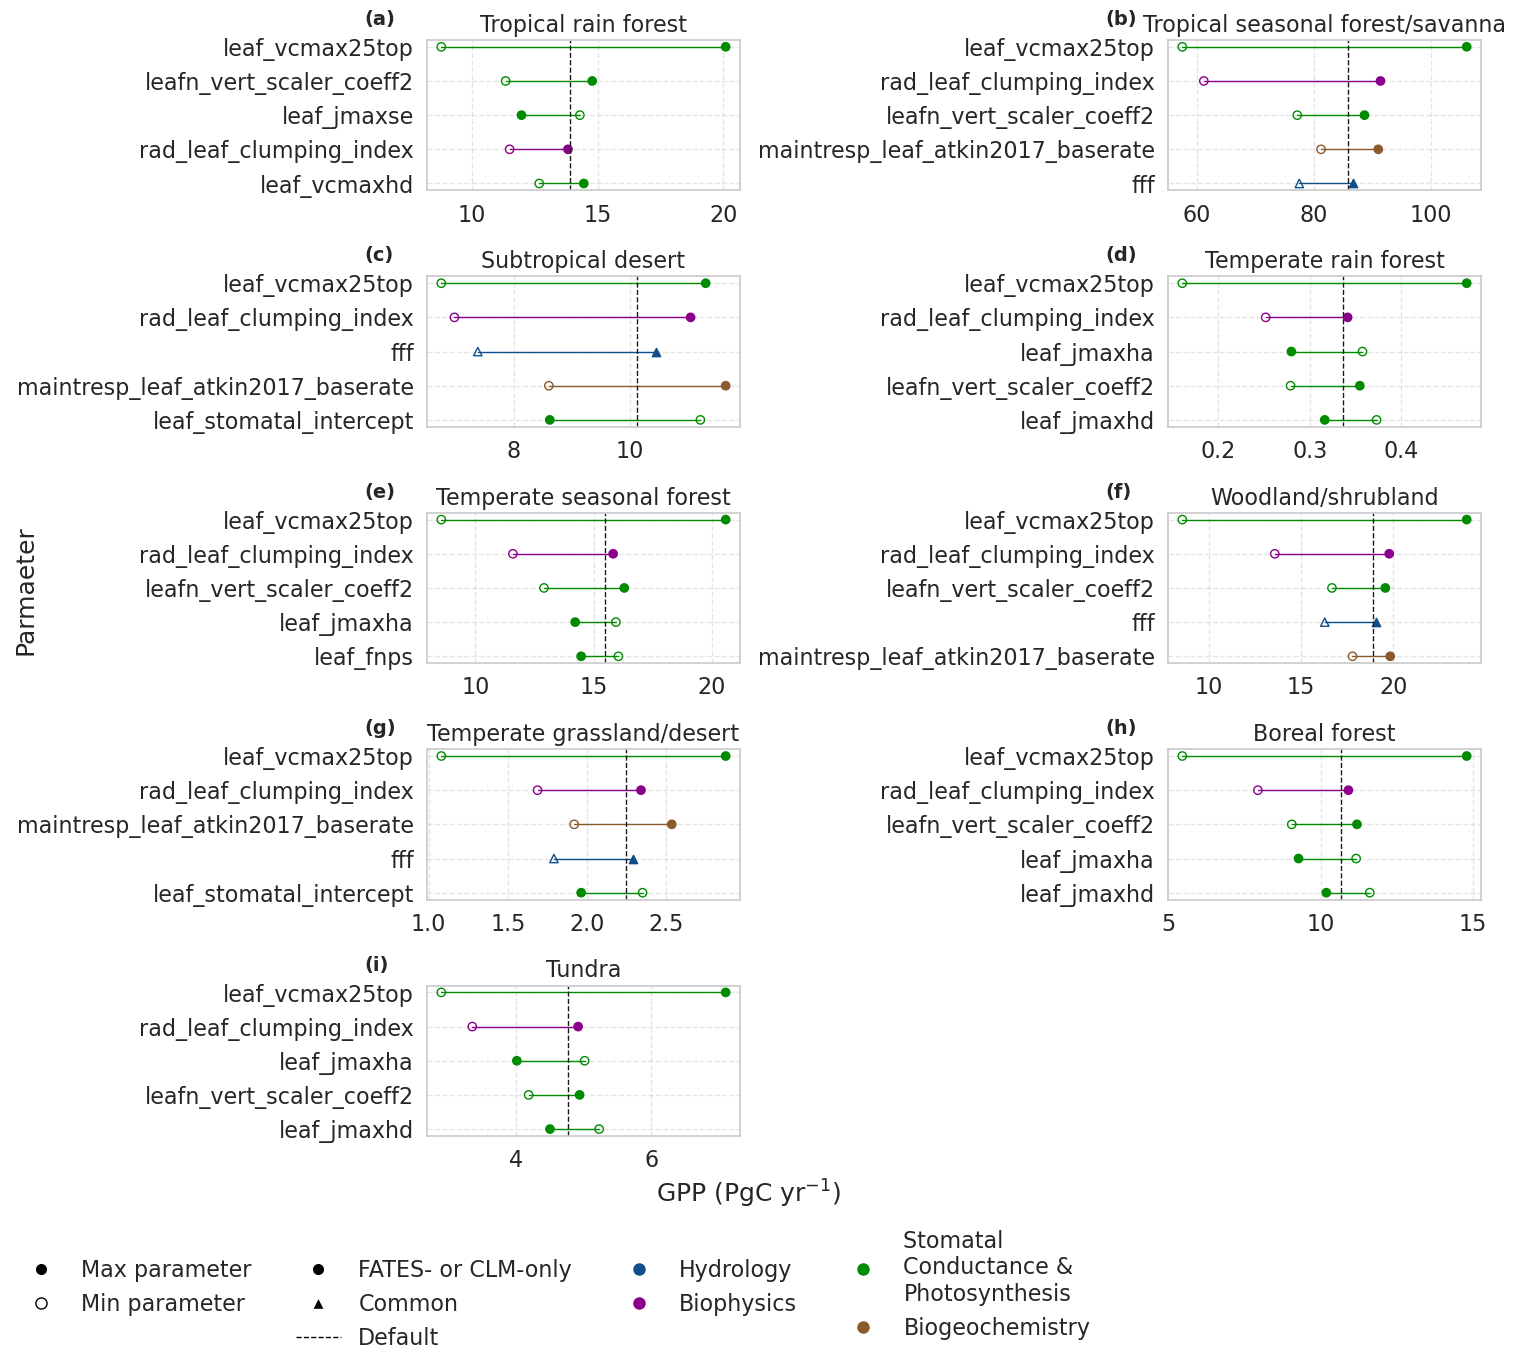

In [58]:
variable = 'GPP'
fates_biome_top5 = oaat.get_biome_top_n(fates_biome_combo_mean, fates_biome_df,
                                        variable, n=5)
clm_biome_top5 = oaat.get_biome_top_n(clm_biome_mean, clm_biome_df,
                                      variable, n=5)
plotting.plot_top_n(fates_biome_top5,
                    fates_biome_combo_mean.sel(ensemble=0),
                    all_params,
                    variable, var_dict[variable]['long_name'],
                    var_dict[variable]['global_units'], by_biomes=True, width=15)
plt.savefig(os.path.join(fig_dir, 'GPP_top5_bybiome_FATES.png'), bbox_inches='tight')

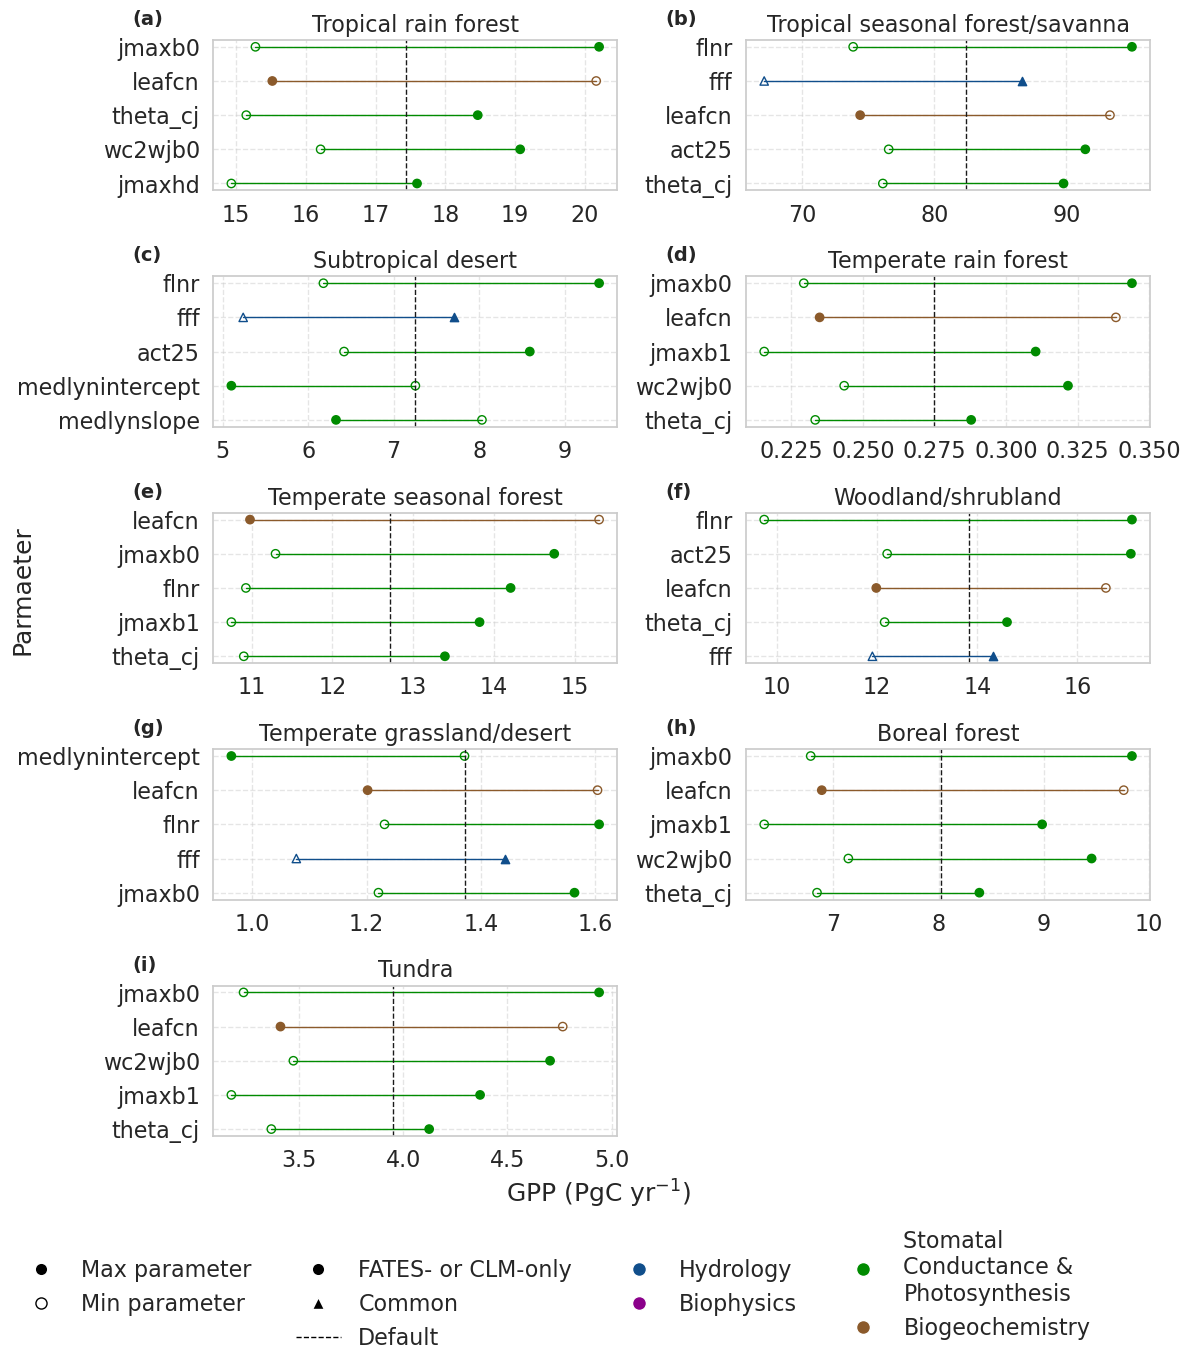

In [59]:
plotting.plot_top_n(clm_biome_top5, clm_biome_mean.sel(ensemble=0),
                    all_params,
                    variable, var_dict[variable]['long_name'],
                    var_dict[variable]['global_units'], by_biomes=True, width=12)
plt.savefig(os.path.join(fig_dir, 'GPP_top5_bybiome_CLM.png'), bbox_inches='tight')

## Differences between models

In [60]:
clm_reldiffs, fates_reldiffs, fatesclm_reldiffs = oaat.get_all_vardiffs([v for v in variables if v != 'WUE'], clm_glob, fates_glob_combo, fates_glob,
                                                                        nonzero_params, 15, reldiff=True)

/glade/work/afoster/FATES_calibration/fates_calibration_library/fates_calibration_library/plotting_functions.py:1591: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['abs_diff'] = np.abs(df_filtered[var_name])
/glade/work/afoster/FATES_calibration/fates_calibration_library/fates_calibration_library/plotting_functions.py:1591: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['abs_diff'] = np.abs(df_filtered[var_name])


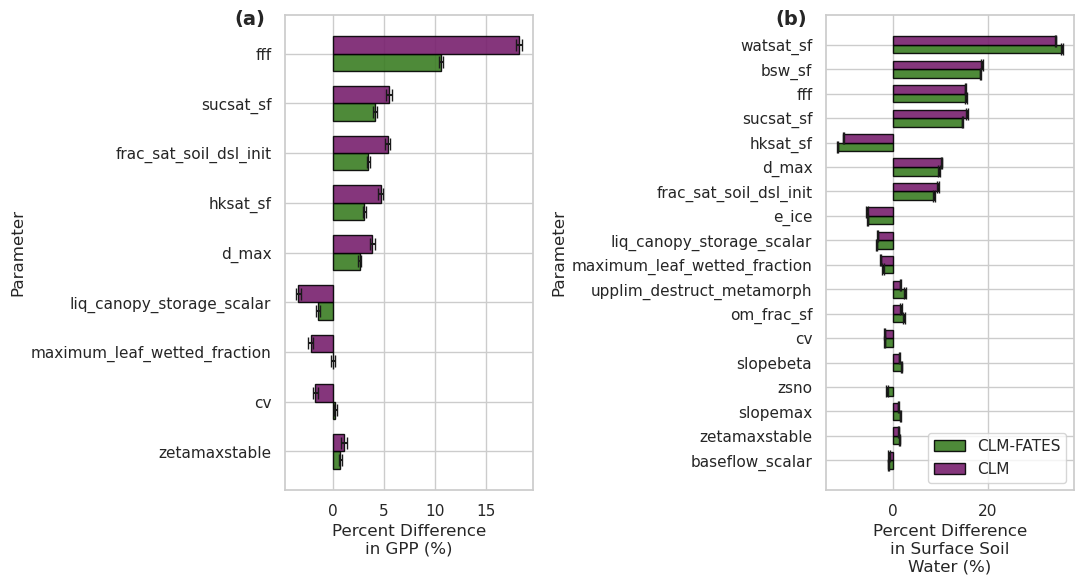

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
axes = axes.flatten()
plotting.plot_var_diff(axes[0], fatesclm_reldiffs, 'GPP', 1, var_dict['GPP']['long_name'], include_sd=True)
plotting.plot_var_diff(axes[1], fatesclm_reldiffs, 'SOILWATER_10CM', 1,
                       var_dict['SOILWATER_10CM']['long_name'], include_sd=True)
axes[1].legend(loc='best')
for k in range(2):
    label = string.ascii_lowercase[k]
    axes[k].text(
        -0.2, 1.01, f"({label})",
        transform=axes[k].transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='left'
    )
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'relative_diffs_GPP.png'), bbox_inches='tight')

In [62]:
param_names = {'turb_leaf_diameter': 'leaf dimension',
             'leaf_stomatal_intercept': 'stomatal intercept',
             'leaf_stomatal_slope_medlyn': 'stomatal slope',
             'leaf_slatop': 'specific leaf area'}
param_order = ['turb_leaf_diameter', 'leaf_slatop', 'leaf_stomatal_intercept',
               'leaf_stomatal_slope_medlyn']

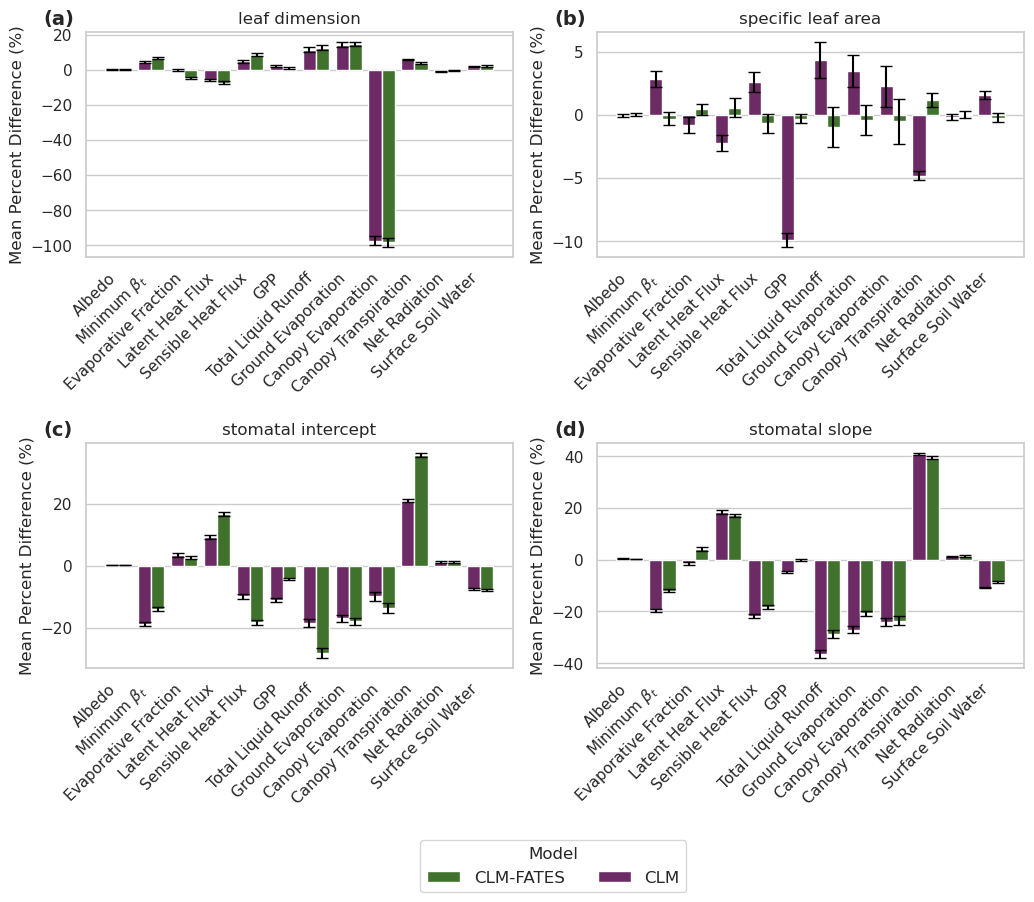

In [63]:
clm_parameters = ['dleaf', 'slatop', 'medlynintercept', 'medlynslope']
fates_parameters = [corresponding_params[param] for param in clm_parameters]
df = oaat.get_compare_df(clm_reldiffs, fates_reldiffs, clm_parameters, fates_parameters)
df['variable_name'] = [var_dict[variable]['long_name'] for variable in df['variable']]
df['model_name'] = ['CLM-FATES' if model == 'FATES' else 'CLM' for model in df['model']]

plotting.plot_multiple_compare_vars(df, fates_parameters, corresponding_params, param_names, param_order)
plt.savefig(os.path.join(fig_dir, 'analagous_params.png'), bbox_inches='tight')

## WUE and BTRAN

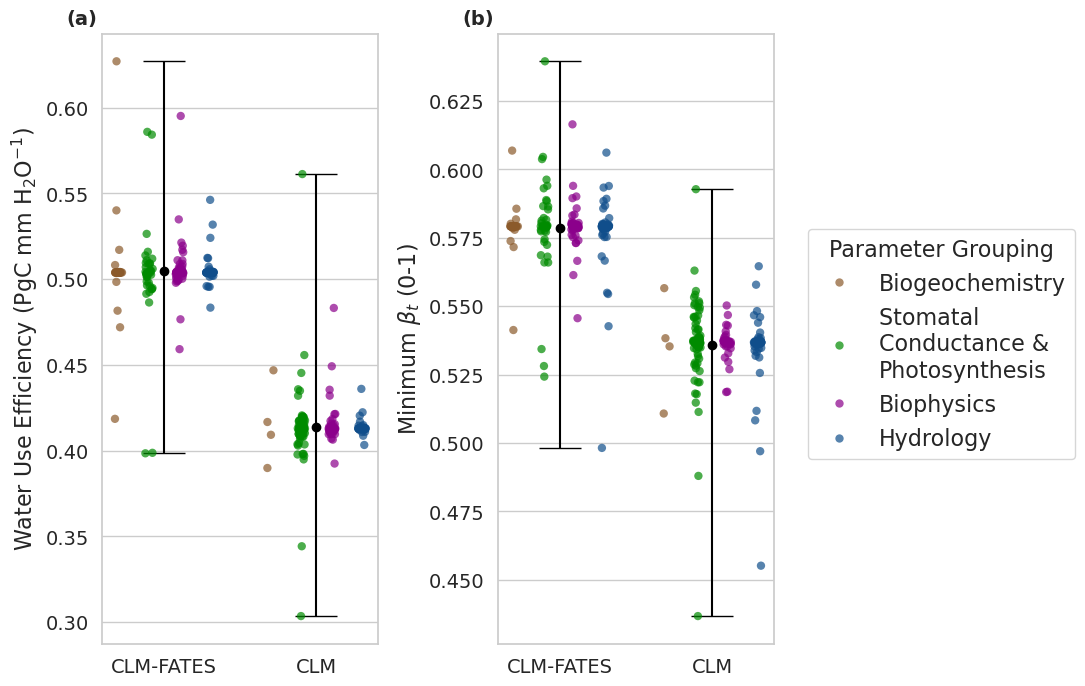

In [64]:
plotting.plot_ensemble_variance(active_df, 'CLM-FATES', 'CLM', fates_default, clm_default,
                                ['WUE', 'BTRANMN'], var_dict, width=8, height=7)
plt.savefig(os.path.join(fig_dir, 'WUE_BTRANMN.png'), bbox_inches="tight")

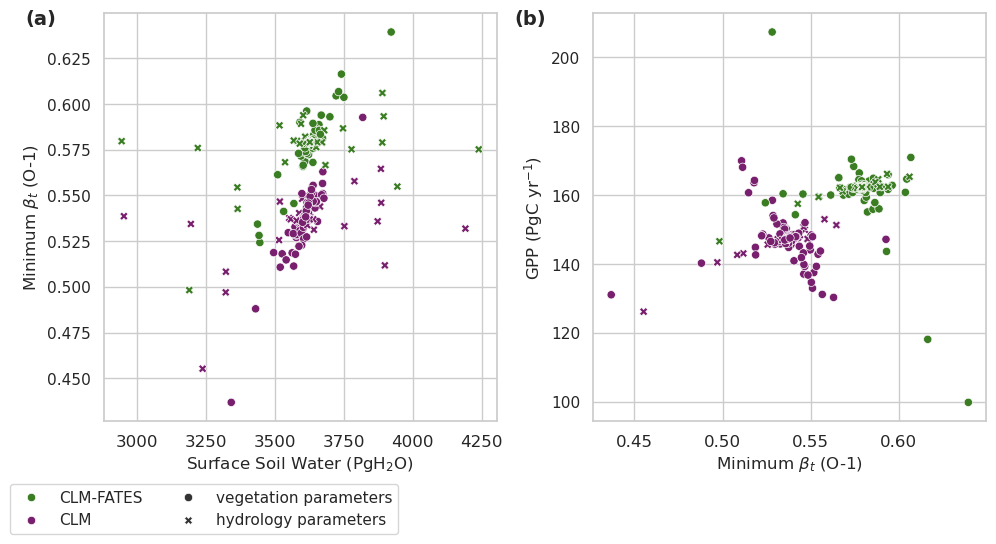

In [65]:
active_df['model_name'] = ['CLM-FATES' if model == 'FATES' else 'CLM' for model in active_df['model']]
active_df['category_subset'] = ['hydrology parameters' if cat == 'hydrology' else 'vegetation parameters' for cat in active_df['category']]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()
sns.scatterplot(data=active_df, x='SOILWATER_10CM', y='BTRANMN',
                hue='model_name',
                hue_order=['CLM-FATES', 'CLM'],
                style='category_subset',
                palette=plotting._MODEL_COLS,
                ax=axes[0])
sns.scatterplot(data=active_df, x='BTRANMN', y='GPP',
                hue='model_name',
                style='category_subset',
                hue_order=['CLM-FATES', 'CLM'],
                palette=plotting._MODEL_COLS,
                ax=axes[1])


# Grab handles/labels and strip the variable titles
handles, labels = axes[1].get_legend_handles_labels()
# Filter out unwanted legend titles
clean_handles_labels = [
    (h, l) for h, l in zip(handles, labels)
    if l not in ["model_name", "category_subset"]
]

# Unpack and make a clean shared legend
handles, labels = zip(*clean_handles_labels)
legend = fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.2, -0.1),
    ncol=2,
    frameon=True
)
legend.set_title(None)

axes[0].set_ylabel(f"{var_dict['BTRANMN']['long_name']} (O-1)")
axes[0].set_xlabel(f"{var_dict['SOILWATER_10CM']['long_name']} ({var_dict['SOILWATER_10CM']['global_units']})");
axes[1].set_xlabel(f"{var_dict['BTRANMN']['long_name']} (O-1)")
axes[1].set_ylabel(f"{var_dict['GPP']['long_name']} ({var_dict['GPP']['global_units']})")
axes[0].get_legend().remove()
axes[1].get_legend().remove()
for k in range(2):
    label = string.ascii_lowercase[k]
    axes[k].text(
        -0.2, 1.01, f"({label})",
        transform=axes[k].transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='left'
    )

for ax in axes:
    ax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'btran_wue_plot.png'), bbox_inches='tight')

## Mini OAAT

In [66]:
fates_meandiffs2 = oaat.get_min_max_diff(fates_glob_combo_mean2, 'FATES')
fates_meandiffs3 = oaat.get_min_max_diff(fates_glob_combo_mean3, 'FATES')

fates_meandiffs2 = fates_meandiffs2[fates_meandiffs2.parameter.isin(['fates_leaf_vcmax25top', 'fates_leaf_stomatal_slope_medlyn',
                                                'fates_leaf_stomatal_intercept', 'fff'])]
fates_meandiffs3 = fates_meandiffs3[fates_meandiffs3.parameter.isin(['fates_leaf_vcmax25top', 'fates_leaf_stomatal_slope_medlyn',
                                                'fates_leaf_stomatal_intercept', 'fff'])]
fates_meandiffs_sub = fates_meandiffs[fates_meandiffs.parameter.isin(['fates_leaf_vcmax25top', 'fates_leaf_stomatal_slope_medlyn',
                                                'fates_leaf_stomatal_intercept', 'fff'])]
clm_meandiffs_sub = clm_meandiffs[clm_meandiffs.parameter.isin(['medlynslope', 'medlynintercept', 'fff'])]

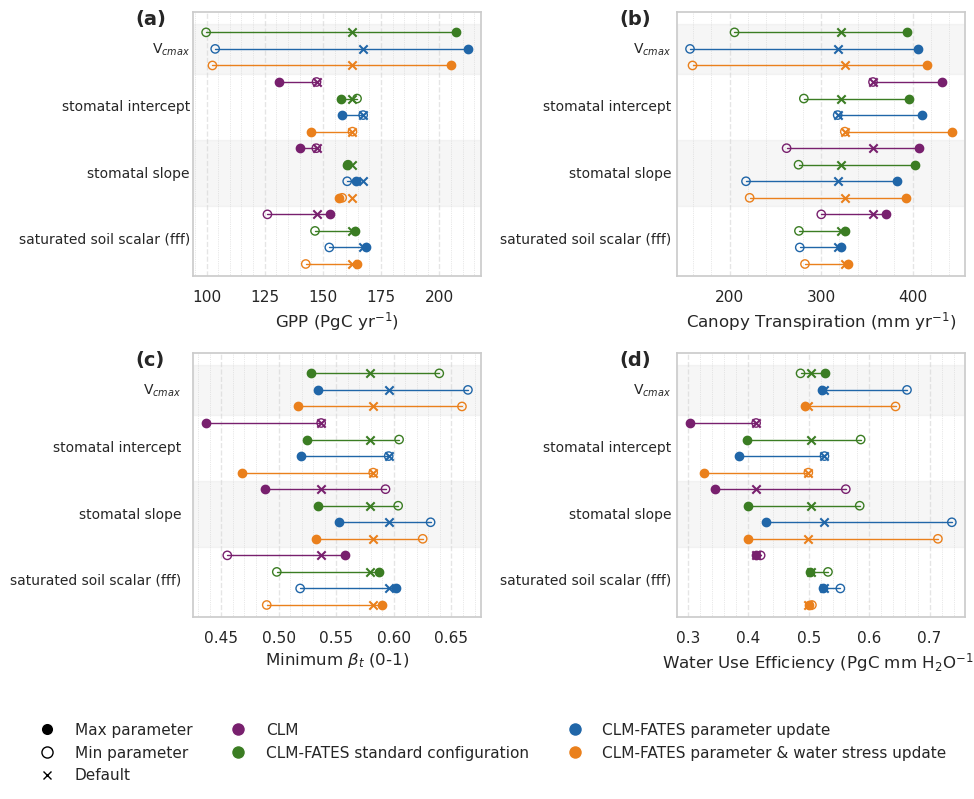

In [67]:
vars_to_plot = ['GPP', 'QVEGT', 'BTRANMN', 'WUE']
long_names = [var_dict[variable]['long_name'] for variable in vars_to_plot]
units = [var_dict[variable]['global_units'] for variable in vars_to_plot]
all_tops = []
for variable in vars_to_plot:
    all_tops.append(oaat.create_combined_mini_oaat_data(variable, fates_glob_combo_mean2, fates_meandiffs2,
                                  fates_glob_combo_mean3, fates_meandiffs3, fates_glob_combo_mean,
                                  fates_meandiffs_sub, clm_mean, clm_meandiffs_sub, corresponding_params))
mvs = [7.0, 20.0, 0.04, 0.14]
plotting.plot_all_mini_oaats(all_tops, long_names, units, mvs, default_line=False)
plt.savefig(os.path.join(fig_dir, 'mini_oaat_figure.png'), bbox_inches='tight')

### Maps

In [68]:
# create a global land frac and area grid
land_frac_ds = os.path.join("/glade/derecho/scratch/afoster/archive",
                            "ctsm60SP_bigleaf_fullgrid/lnd/hist",
                            "ctsm60SP_bigleaf_fullgrid.clm2.h0.0001-02-01-00000.nc")
target_grid = clm.create_target_grid(land_frac_ds, 'FSR')
ds_frac = xr.Dataset({'landfrac': target_grid.landfrac,
                      'landarea': target_grid.land_area})

In [69]:
# read in global datasets
fates_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_annual_maps.nc"))
fates_maps_ens = fates_maps.where(fates_maps.ensemble > fates['default'], drop=True)
fates_maps_ens = xr.merge([fates_maps_ens, fates_param_dat])

fates_maps2 = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_2_annual_maps.nc"))
fates_maps_ens2 = fates_maps2.where(fates_maps2.ensemble > fates['default'], drop=True)
fates_maps_ens2 = xr.merge([fates_maps_ens2, fates_param_dat2])

fates_maps3 = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_3_annual_maps.nc"))
fates_maps_ens3 = fates_maps3.where(fates_maps3.ensemble > fates['default'], drop=True)
fates_maps_ens3 = xr.merge([fates_maps_ens3, fates_param_dat3])

fates_clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates_clm['name']}_annual_maps.nc"))
fates_clm_maps_ens = fates_clm_maps.where(fates_clm_maps.ensemble > fates_clm['default'], drop=True)
fates_clm_maps_ens = xr.merge([fates_clm_maps_ens, clm_param_dat])

clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{clm_oaat['name']}_annual_maps.nc"))
clm_maps_ens = clm_maps.where(clm_maps.ensemble > clm_oaat['default'], drop=True)
clm_maps_ens = xr.merge([clm_maps_ens, clm_param_dat])

In [70]:
fates_ens_default = fates_maps.sel(ensemble=0)
fates_ens_default2 = fates_maps2.sel(ensemble=0)
fates_ens_default3 = fates_maps3.sel(ensemble=0)

fates_ens_default['WUE'] = fates_ens_default['GPP']*1000/(fates_ens_default['QVEGT'].where(fates_ens_default.QVEGT > 0.0))
fates_ens_default2['WUE'] = fates_ens_default2['GPP']*1000/(fates_ens_default2['QVEGT'].where(fates_ens_default2.QVEGT > 0.0))
fates_ens_default3['WUE'] = fates_ens_default3['GPP']*1000/(fates_ens_default3['QVEGT'].where(fates_ens_default3.QVEGT > 0.0))

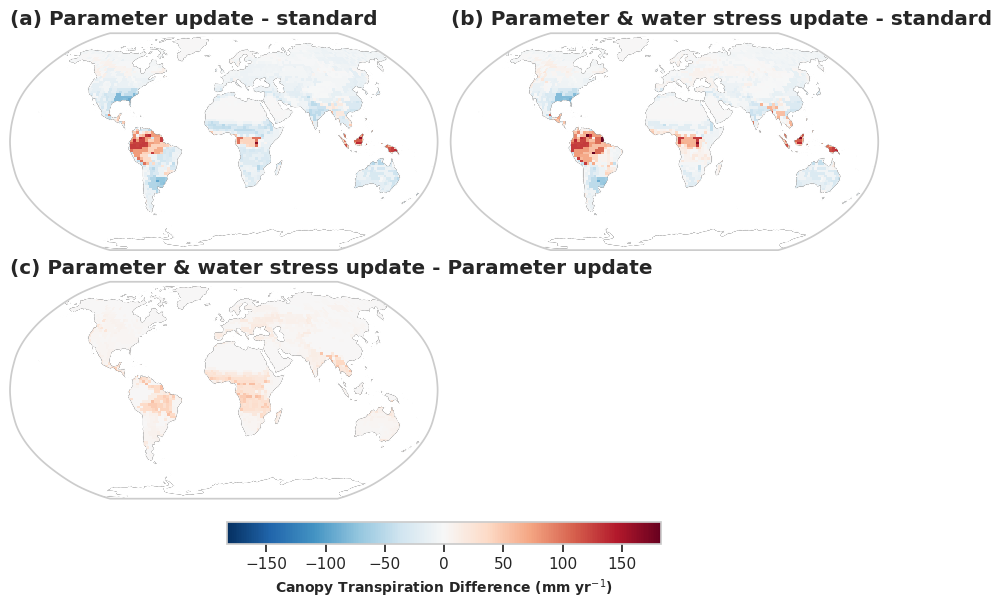

In [71]:
variable = 'QVEGT'
long_name = var_dict[variable]['long_name']
units = var_dict[variable]['annual_units']
diff2_0 = fates_ens_default2[variable]*ds_frac.landfrac - fates_ens_default[variable]*ds_frac.landfrac
diff3_2 = fates_ens_default3[variable]*ds_frac.landfrac - fates_ens_default2[variable]*ds_frac.landfrac
diff3_0 = fates_ens_default3[variable]*ds_frac.landfrac - fates_ens_default[variable]*ds_frac.landfrac

vmax = np.max([np.abs(diff2_0).max(), np.abs(diff3_2).max(), np.abs(diff3_0).max()])

figure, axes = plotting.generate_subplots(3)
axes = axes.flatten()
plotting.map_function(
    axes[0], diff2_0, '(a) Parameter update - standard', 'RdBu_r', vmin=vmax*-1, vmax=vmax, diverging_cmap=False)
plotting.map_function(
    axes[1], diff3_2, '(c) Parameter & water stress update - Parameter update', 'RdBu_r', vmin=vmax*-1, vmax=vmax, diverging_cmap=False)
pcm = plotting.map_function(
    axes[2], diff3_0, '(b) Parameter & water stress update - standard', 'RdBu_r', vmin=vmax*-1, vmax=vmax, diverging_cmap=False)
cbar = figure.colorbar(
    pcm, ax=axes.ravel().tolist(), shrink=0.5, orientation="horizontal"
)
cbar.set_label(f"{long_name} Difference ({units})", size=10, fontweight="bold")
plt.savefig(os.path.join(fig_dir, 'supplementary_figs',  'QVEGT_global_updates.png'), bbox_inches='tight')

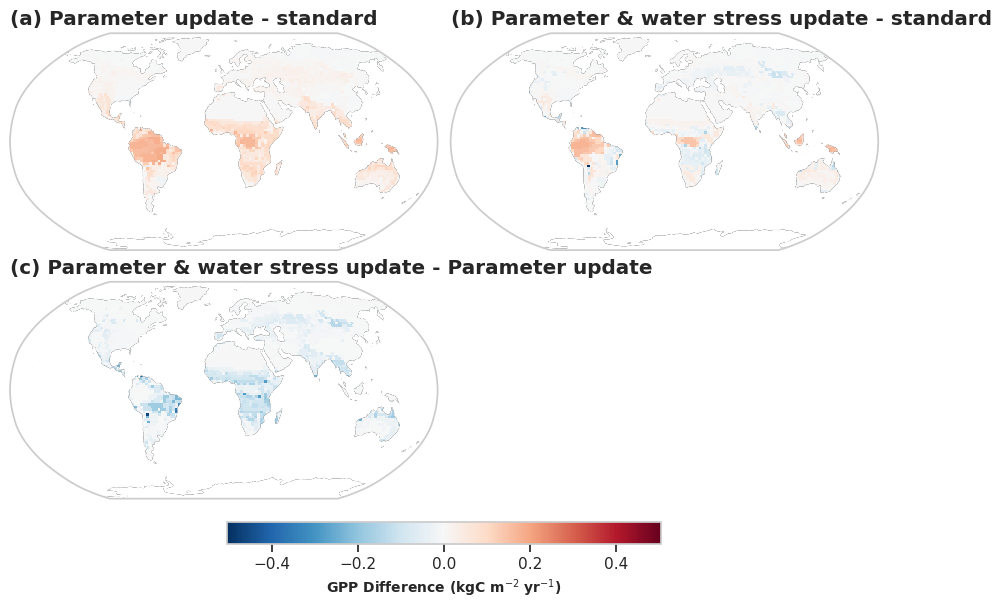

In [72]:
variable = 'GPP'
long_name = var_dict[variable]['long_name']
units = var_dict[variable]['annual_units']
diff2_0 = fates_ens_default2[variable]*ds_frac.landfrac - fates_ens_default[variable]*ds_frac.landfrac
diff3_2 = fates_ens_default3[variable]*ds_frac.landfrac - fates_ens_default2[variable]*ds_frac.landfrac
diff3_0 = fates_ens_default3[variable]*ds_frac.landfrac - fates_ens_default[variable]*ds_frac.landfrac

vmax = np.max([np.abs(diff2_0).max(), np.abs(diff3_2).max(), np.abs(diff3_0).max()])

figure, axes = plotting.generate_subplots(3)
axes = axes.flatten()
plotting.map_function(
    axes[0], diff2_0, '(a) Parameter update - standard', 'RdBu_r', vmin=vmax*-1, vmax=vmax, diverging_cmap=False)
plotting.map_function(
    axes[1], diff3_2, '(c) Parameter & water stress update - Parameter update', 'RdBu_r', vmin=vmax*-1, vmax=vmax, diverging_cmap=False)
pcm = plotting.map_function(
    axes[2], diff3_0, '(b) Parameter & water stress update - standard', 'RdBu_r', vmin=vmax*-1, vmax=vmax, diverging_cmap=False)
cbar = figure.colorbar(
    pcm, ax=axes.ravel().tolist(), shrink=0.5, orientation="horizontal"
)
cbar.set_label(f"{long_name} Difference ({units})", size=10, fontweight="bold")
plt.savefig(os.path.join(fig_dir, 'supplementary_figs', 'GPP_global_updates.png'), bbox_inches='tight')

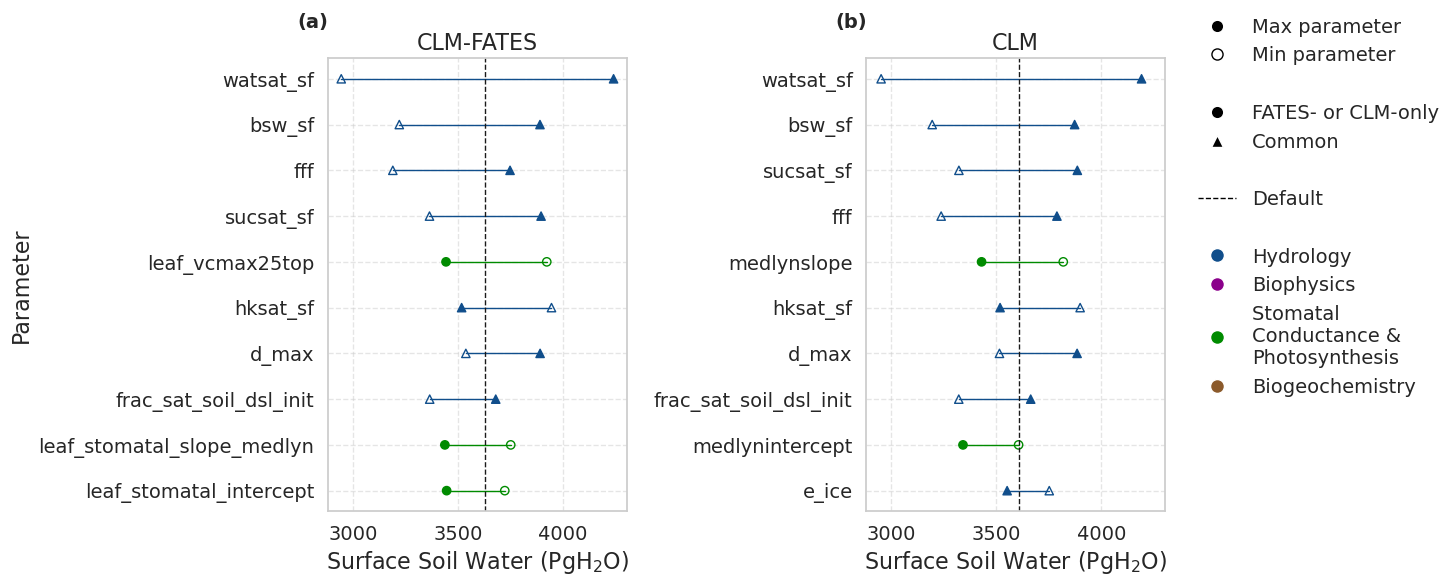

In [73]:
variable = 'SOILWATER_10CM'
n = 10

fates_top10 = oaat.get_top_n(fates_glob_combo_mean, fates_meandiffs, variable,
                             n, fates_glob_combo_mean.sel(ensemble=0))
clm_top10 = oaat.get_top_n(clm_mean, clm_meandiffs, variable, n,
                           clm_mean.sel(ensemble=0))
plotting.plot_2_top_n(fates_top10, clm_top10, fates_glob_combo_mean.sel(ensemble=0),
                      clm_mean.sel(ensemble=0), all_params, variable,
                      var_dict[variable]['long_name'],
                      var_dict[variable]['global_units'])
plt.savefig(os.path.join(fig_dir, 'supplementary_figs', 'SW_top_10.png'),
            bbox_inches='tight')

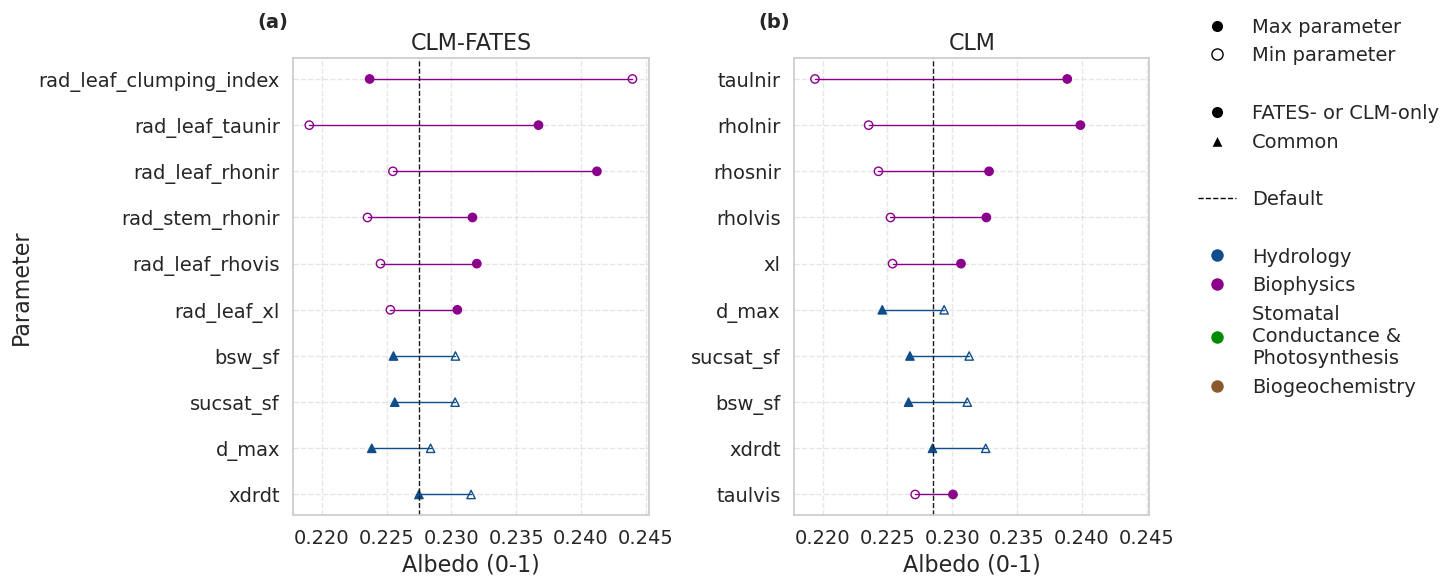

In [74]:
variable = 'ASA'
n = 10

fates_top10 = oaat.get_top_n(fates_glob_combo_mean, fates_meandiffs, variable,
                             n, fates_glob_combo_mean.sel(ensemble=0))
clm_top10 = oaat.get_top_n(clm_mean, clm_meandiffs, variable, n,
                           clm_mean.sel(ensemble=0))
plotting.plot_2_top_n(fates_top10, clm_top10, fates_glob_combo_mean.sel(ensemble=0),
                      clm_mean.sel(ensemble=0), all_params, variable,
                      var_dict[variable]['long_name'],
                      var_dict[variable]['global_units'])
plt.savefig(os.path.join(fig_dir, 'supplementary_figs', 'ASA_top_10.png'),
            bbox_inches='tight')

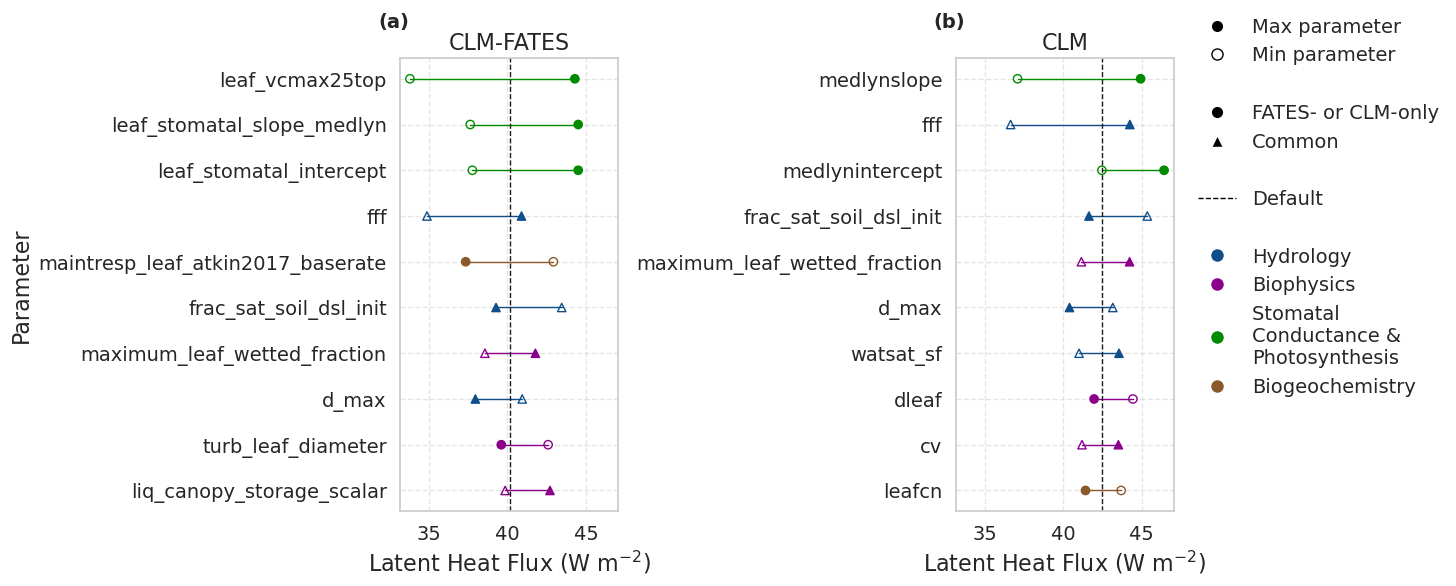

In [75]:
variable = 'EFLX_LH_TOT'
n = 10

fates_top10 = oaat.get_top_n(fates_glob_combo_mean, fates_meandiffs, variable,
                             n, fates_glob_combo_mean.sel(ensemble=0))
clm_top10 = oaat.get_top_n(clm_mean, clm_meandiffs, variable, n,
                           clm_mean.sel(ensemble=0))
plotting.plot_2_top_n(fates_top10, clm_top10, fates_glob_combo_mean.sel(ensemble=0),
                      clm_mean.sel(ensemble=0), all_params, variable,
                      var_dict[variable]['long_name'],
                      var_dict[variable]['global_units'])
plt.savefig(os.path.join(fig_dir, 'supplementary_figs', 'EFLX_LH_top_10.png'),
            bbox_inches='tight')

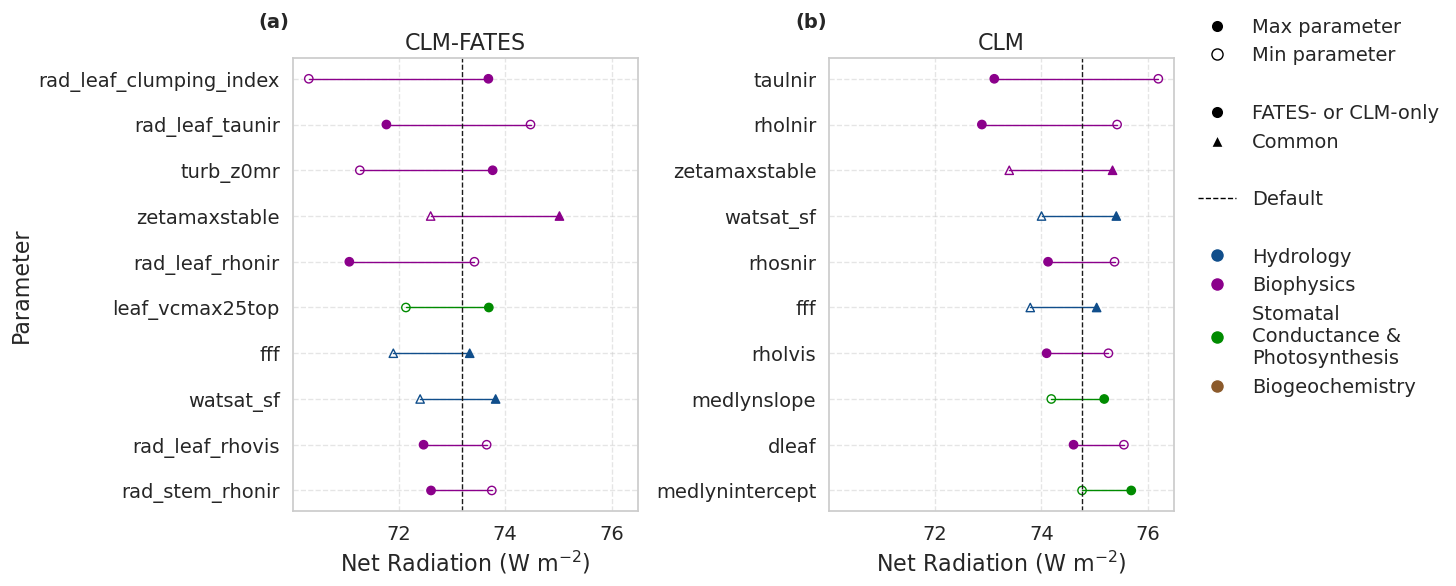

In [76]:
variable = 'RN'
n = 10

fates_top10 = oaat.get_top_n(fates_glob_combo_mean, fates_meandiffs, variable,
                             n, fates_glob_combo_mean.sel(ensemble=0))
clm_top10 = oaat.get_top_n(clm_mean, clm_meandiffs, variable, n,
                           clm_mean.sel(ensemble=0))
plotting.plot_2_top_n(fates_top10, clm_top10, fates_glob_combo_mean.sel(ensemble=0),
                      clm_mean.sel(ensemble=0), all_params, variable,
                      var_dict[variable]['long_name'],
                      var_dict[variable]['global_units'])
plt.savefig(os.path.join(fig_dir, 'supplementary_figs', 'RN_top_10.png'),
            bbox_inches='tight')